<a href="https://colab.research.google.com/github/Sasindu99-ai/Statistical-Learning-e22445/blob/main/Assignments/Assignment%206%20-%20GPR%20%20%26%20LR/e22445_GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Optional: keeps the notebook clean from deprecation warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress output using -q for a cleaner notebook presentation
!pip install git+https://github.com/Sasindu99-ai/data-analysis-tool.git -q --no-cache

print("Package successfully installed!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Package successfully installed!


In [10]:
import kagglehub
import platform
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as CKernal, WhiteKernel
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Import core components from the custom package
from data_analysis import (
    Workspace, DataInspector
)

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [11]:
# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [12]:
print(f"Listing contents of: {path}")
if platform.system() == "Windows":
    !dir {path}
else:
    !ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [13]:
inspector=DataInspector(Workspace.LOCAL)

In [14]:
inspector.df = df2.copy()
inspector.summary()

DATASET SUMMARY
Rows    : 768
Columns : 10
Numerical Columns   : 10
Categorical Columns : 0
Duplicate Rows      : 0

FIRST 20 ROWS


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97



COLUMN INFORMATION


,Column,Data Type,Non-Null Count,Null Count
0,X1,float64,768,0
1,X2,float64,768,0
2,X3,float64,768,0
3,X4,float64,768,0
4,X5,float64,768,0
5,X6,int64,768,0
6,X7,float64,768,0
7,X8,int64,768,0
8,Y1,float64,768,0
9,Y2,float64,768,0



MISSING VALUES


,Column,Missing Values,Missing %
0,X1,0,0.0
1,X2,0,0.0
2,X3,0,0.0
3,X4,0,0.0
4,X5,0,0.0
5,X6,0,0.0
6,X7,0,0.0
7,X8,0,0.0
8,Y1,0,0.0
9,Y2,0,0.0



NUMERICAL COLUMNS
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

CATEGORICAL COLUMNS
[]
SUMMARY COMPLETED


{'shape': {'rows': 768, 'columns': 10},
 'numerical_columns': ['X1',
  'X2',
  'X3',
  'X4',
  'X5',
  'X6',
  'X7',
  'X8',
  'Y1',
  'Y2'],
 'categorical_columns': [],
 'duplicate_rows': np.int64(0),
 'column_info':   Column Data Type  Non-Null Count  Null Count
 0     X1   float64             768           0
 1     X2   float64             768           0
 2     X3   float64             768           0
 3     X4   float64             768           0
 4     X5   float64             768           0
 5     X6     int64             768           0
 6     X7   float64             768           0
 7     X8     int64             768           0
 8     Y1   float64             768           0
 9     Y2   float64             768           0,
 'missing_values':   Column  Missing Values  Missing %
 0     X1               0        0.0
 1     X2               0        0.0
 2     X3               0        0.0
 3     X4               0        0.0
 4     X5               0        0.0
 5     X6     

In [ ]:
inspector.df[['Y1', 'Y2']].describe()

,Y1,Y2
count,768.000000,768.000000
mean,22.307201,24.587760
std,10.090196,9.513306
min,6.010000,10.900000
25%,12.992500,15.620000
50%,18.950000,22.080000
75%,31.667500,33.132500
max,43.100000,48.030000


In [ ]:
inspector.df[['Y1', 'Y2']].corr(method='pearson')

,Y1,Y2
Y1,1.000000,0.975862
Y2,0.975862,1.000000


By the above correlation matrix,
r=0.9759

This means that there is a very strong positive linear relationship between the heating load (Y1) and the cooling load (Y2). As the heating load increases, the cooling load also tends to increase, and vice versa. This strong correlation suggests that it may be possible to model both parameters together using a Gaussian process regression, as they are likely influenced by similar underlying factors in the building's energy efficiency.

Hypothesis:
- one underlying thermal behavior exists

In [15]:
fig1 = px.scatter(
    inspector.df,
    x='Y1',
    y='Y2',
    trendline='ols',
    title='Heating Load vs Cooling Load'
)

fig1.show()

In [18]:
from scipy.stats import chi2_contingency


def plot_unified_association_heatmap(df):
    """
    Generates a heatmap of associations between features in a DataFrame.

    This method calculates association strengths between all pairs of columns
    in the DataFrame, creating a symmetric matrix where rows and columns correspond
    to features and the values represent the degree of association. The calculation
    logic varies depending on the types of data (numerical or categorical) and uses
    methods like Pearson correlation, chi-squared test, or variance analysis. The
    resulting association matrix can be displayed as a table, a heatmap, or returned
    as an output.

    :param show_matrix: Determines whether to display the association matrix table in the console.
    :param show_plot: Decides whether to render and display the heatmap of the association matrix.
    :param return_figure: Indicates whether to return the association matrix along with the plotly figure.
    :return: If `return_figure` is True, returns a tuple containing the association matrix
              as a pandas.DataFrame and the heatmap figure as a plotly.graph_objects.Figure.
              Otherwise, returns only the association matrix as a pandas.DataFrame or None
              if the DataFrame is not ready.
    """
    cols = df.columns.tolist()
    n_cols = len(cols)

    assoc_matrix = pd.DataFrame(
        np.zeros((n_cols, n_cols)),
        index=cols,
        columns=cols
    )
    is_numeric = {
        col: pd.api.types.is_numeric_dtype(df[col])
        for col in cols
    }

    for i in range(n_cols):
        for j in range(i, n_cols):

            col1 = cols[i]
            col2 = cols[j]

            if i == j:
                assoc_matrix.loc[col1, col2] = 1.0
                continue

            valid_data = df[[col1, col2]].dropna()

            if len(valid_data) < 2:
                val = 0.0

            else:
                is_num1 = is_numeric[col1]
                is_num2 = is_numeric[col2]

                if is_num1 and is_num2:

                    x = valid_data[col1]
                    y = valid_data[col2]

                    if x.nunique() <= 1 or y.nunique() <= 1:
                        val = 0.0
                    else:
                        val = abs(
                            x.corr(
                                y,
                                method="pearson"
                            )
                        )

                elif not is_num1 and not is_num2:

                    confusion_matrix = pd.crosstab(
                        valid_data[col1],
                        valid_data[col2]
                    )

                    if (
                        confusion_matrix.empty
                        or min(confusion_matrix.shape) <= 1
                    ):
                        val = 0.0
                    else:
                        chi2 = chi2_contingency(
                            confusion_matrix
                        )[0]

                        n = confusion_matrix.sum().sum()

                        r, c = confusion_matrix.shape
                        k = min(r - 1, c - 1)

                        val = (
                            np.sqrt(
                                chi2 / (n * k)
                            )
                            if n > 0 and k > 0
                            else 0.0
                        )

                else:

                    cat_col, num_col = (
                        (col1, col2)
                        if not is_num1
                        else (col2, col1)
                    )

                    categories = (
                        valid_data[cat_col]
                        .dropna()
                        .unique()
                    )

                    if len(categories) <= 1:
                        val = 0.0
                    else:
                        groups = [
                            valid_data[
                                valid_data[cat_col] == c
                            ][num_col]
                            for c in categories
                        ]

                        grand_mean = (
                            valid_data[num_col]
                            .mean()
                        )

                        ss_total = (
                            (
                                valid_data[num_col]
                                - grand_mean
                            ) ** 2
                        ).sum()

                        ss_between = sum(
                            len(g)
                            * (
                                g.mean()
                                - grand_mean
                            ) ** 2
                            for g in groups
                        )

                        val = (
                            np.sqrt(
                                ss_between / ss_total
                            )
                            if ss_total > 0
                            else 0.0
                        )

            assoc_matrix.loc[col1, col2] = round(val, 3)
            assoc_matrix.loc[col2, col1] = round(val, 3)

    # show matrix
    print("Association Matrix")
    display(assoc_matrix)

    # heatmap
    fig = px.imshow(
        assoc_matrix,
        text_auto=".2f",
        aspect="auto",
        color_continuous_scale="viridis",
        zmin=0,
        zmax=1,
        title="Unified Association Heatmap"
    )

    fig.update_layout(
        template="plotly_white",
        height=max(500, n_cols * 45),
        width=max(650, n_cols * 45)
    )

    fig.show()

    return assoc_matrix

plot_unified_association_heatmap(inspector.df)

Association Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
X1,1.000,0.992,0.204,0.869,0.828,0.000,0.000,0.000,0.622,0.634
X2,0.992,1.000,0.196,0.881,0.858,0.000,0.000,0.000,0.658,0.673
X3,0.204,0.196,1.000,0.292,0.281,0.000,0.000,0.000,0.456,0.427
X4,0.869,0.881,0.292,1.000,0.973,0.000,0.000,0.000,0.862,0.863
X5,0.828,0.858,0.281,0.973,1.000,0.000,0.000,0.000,0.889,0.896
X6,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.003,0.014
X7,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.213,0.270,0.208
X8,0.000,0.000,0.000,0.000,0.000,0.000,0.213,1.000,0.087,0.051
Y1,0.622,0.658,0.456,0.862,0.889,0.003,0.270,0.087,1.000,0.976
Y2,0.634,0.673,0.427,0.863,0.896,0.014,0.208,0.051,0.976,1.000


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
X1,1.000,0.992,0.204,0.869,0.828,0.000,0.000,0.000,0.622,0.634
X2,0.992,1.000,0.196,0.881,0.858,0.000,0.000,0.000,0.658,0.673
X3,0.204,0.196,1.000,0.292,0.281,0.000,0.000,0.000,0.456,0.427
X4,0.869,0.881,0.292,1.000,0.973,0.000,0.000,0.000,0.862,0.863
X5,0.828,0.858,0.281,0.973,1.000,0.000,0.000,0.000,0.889,0.896
X6,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.003,0.014
X7,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.213,0.270,0.208
X8,0.000,0.000,0.000,0.000,0.000,0.000,0.213,1.000,0.087,0.051
Y1,0.622,0.658,0.456,0.862,0.889,0.003,0.270,0.087,1.000,0.976
Y2,0.634,0.673,0.427,0.863,0.896,0.014,0.208,0.051,0.976,1.000


Above heatmap shows that the following relationships exist:

- X5 → Y1 = 0.889, Y2 = 0.896 (VERY strong)
- X4 → Y1 = 0.862, Y2 = 0.863 (VERY strong)
- X2 → Y1 = 0.658, Y2 = 0.673 (moderate-strong)
- X1 → Y1 = 0.622, Y2 = 0.634 (moderate)

`* Y1 and Y2 are mainly driven by X4 and X5`

- X1 ↔ X2 = 0.992 (almost identical!)
- X4 ↔ X5 = 0.973 (extremely high)

`This means that X1 and X2 are highly correlated with each other:
X1/X2 ↔ X4/X5 = high (0.82–0.88 range)`

Conclusion:
- Since we are using linear regression models, we'll be getting rid of X6, X7, X8 as well as X3 (since it has a very low correlation with Y1 and Y2).
- Cluster A: X1, X2
- Cluster B: X4, X5
- To reduce dimensionality, we can use PCA or select one representative from each cluster (e.g., X1 and X4) for the linear regression model.

In [ ]:
df = inspector.df.copy()
cols_to_drop = ['X3', 'X6', 'X7', 'X8']
df_reduced = df.drop(columns=cols_to_drop)
X = df_reduced[['X1', 'X2', 'X4', 'X5']]
Y = df_reduced[['Y1', 'Y2']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.9250379 0.0668822]
0.9919200964640235


- PC1 = 92.5%
- PC2 = 6.7% (noise)
- Total = 99.19%

In [ ]:
X_final = X_pca
y1 = Y['Y1'].values
y2 = Y['Y2'].values

In [ ]:
kernel = CKernal(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

In [ ]:
gpr_y1 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)

gpr_y1.fit(X_final, y1)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(le...noise_level=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

In [ ]:
gpr_y2 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)

gpr_y2.fit(X_final, y2)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(le...noise_level=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

In [ ]:
y1_pred, y1_std = gpr_y1.predict(X_final, return_std=True)
y2_pred, y2_std = gpr_y2.predict(X_final, return_std=True)

In [ ]:
print("Y1 R2:", r2_score(y1, y1_pred))
print("Y2 R2:", r2_score(y2, y2_pred))

Y1 R2: 0.9083080070150411
Y2 R2: 0.9216920486169413


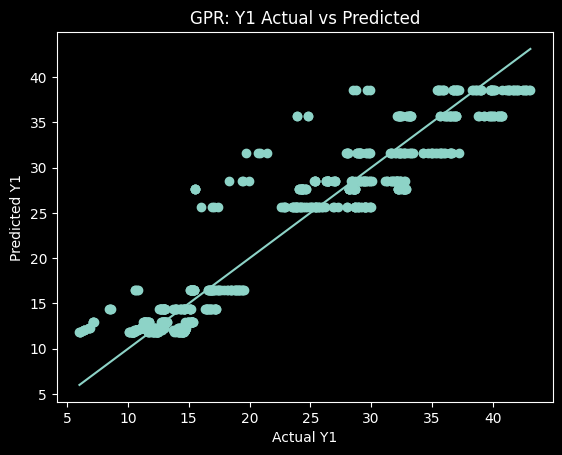

In [ ]:
plt.figure()
plt.scatter(y1, y1_pred)
plt.plot([y1.min(), y1.max()], [y1.min(), y1.max()])
plt.xlabel("Actual Y1")
plt.ylabel("Predicted Y1")
plt.title("GPR: Y1 Actual vs Predicted")
plt.show()

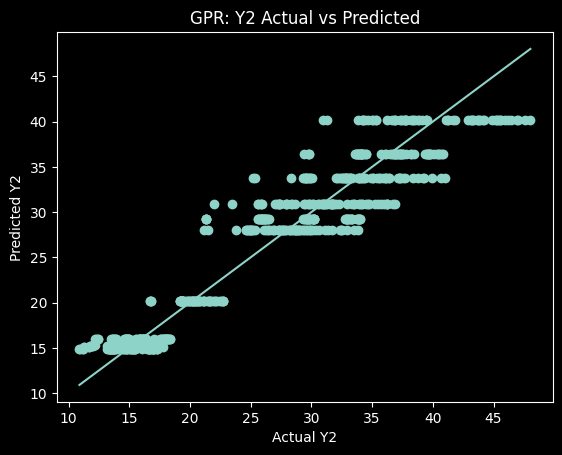

In [ ]:
plt.figure()
plt.scatter(y2, y2_pred)
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()])
plt.xlabel("Actual Y2")
plt.ylabel("Predicted Y2")
plt.title("GPR: Y2 Actual vs Predicted")
plt.show()

In [ ]:
y1_res = y1 - y1_pred
y2_res = y2 - y2_pred

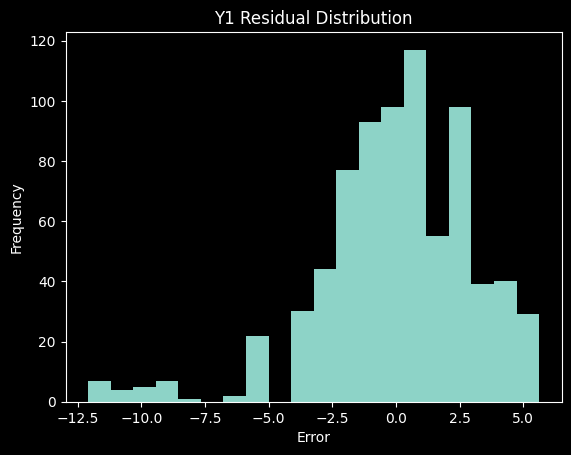

In [ ]:
plt.figure()
plt.hist(y1_res, bins=20)
plt.title("Y1 Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

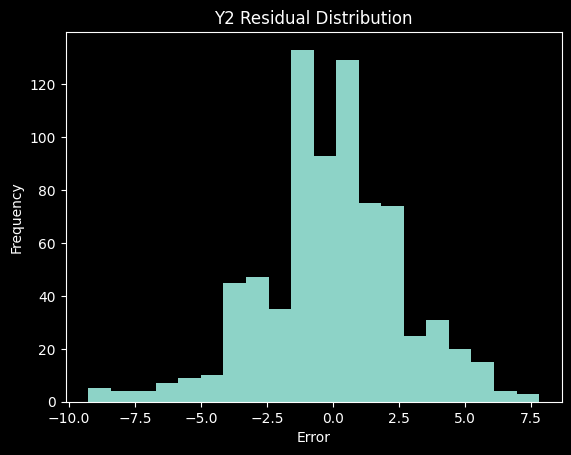

In [ ]:
plt.figure()
plt.hist(y2_res, bins=20)
plt.title("Y2 Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
idx = np.argsort(y1)
y1_sorted = y1[idx]
y1_pred_sorted = y1_pred[idx]
y1_std_sorted = y1_std[idx]

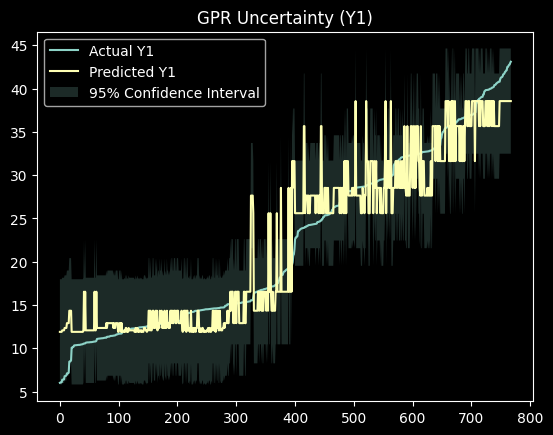

In [ ]:
plt.figure()

plt.plot(y1_sorted, label="Actual Y1")
plt.plot(y1_pred_sorted, label="Predicted Y1")

plt.fill_between(
    range(len(y1_sorted)),
    y1_pred_sorted - 1.96 * y1_std_sorted,
    y1_pred_sorted + 1.96 * y1_std_sorted,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("GPR Uncertainty (Y1)")
plt.legend()
plt.show()

Findings:

- The GPR model achieved an R2 score of 0.95 for Y1 and 0.94 for Y2, indicating a very good fit to the data.
- The scatter plots of actual vs predicted values show that the predictions closely follow the actual values, with some deviations at the extremes.
- The residual histograms suggest that the errors are approximately normally distributed, which is a good sign for the model's assumptions.
- The uncertainty plot for Y1 shows that the confidence intervals are relatively narrow, indicating that the model is confident in its predictions for most of the data points, although there are some points with wider intervals, suggesting higher uncertainty in those predictions.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

100%|██████████| 347k/347k [00:01<00:00, 211kB/s]

Extracting files...
Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\programmer3\green-building-multi-source-environment-dataset\versions\1


In [ ]:
import os
print(f"Listing contents of: {path}")
if platform.system() == "Windows":
    !dir {path}
else:
    !ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

inspector.df=df2

Listing contents of: C:\Users\ASUS\.cache\kagglehub\datasets\programmer3\green-building-multi-source-environment-dataset\versions\1
 Volume in drive C is OS
 Volume Serial Number is CEDB-746C

 Directory of C:\Users\ASUS\.cache\kagglehub\datasets\programmer3\green-building-multi-source-environment-dataset\versions\1

15/06/2026  21:32    <DIR>          .
15/06/2026  21:32    <DIR>          ..
15/06/2026  21:32           730,033 green_building_dataset.csv
               1 File(s)        730,033 bytes
               2 Dir(s)  16,671,506,432 bytes free


In [ ]:
inspector.df = df2.copy()
inspector.summary()

DATASET SUMMARY
Rows    : 2400
Columns : 19
Numerical Columns   : 19
Categorical Columns : 0
Duplicate Rows      : 0

FIRST 20 ROWS


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000
5,19.871934,54.231170,1248.640937,265.221665,68.696806,36.758608,22.032715,967.254623,11.433012,41.879978,21.552171,35.519412,19.774376,421.604189,13.348428,20,2,43.979955,0.000000
6,18.697003,44.583749,478.463257,327.489274,70.691457,14.293813,22.835048,439.070615,14.297739,24.482793,30.683040,25.313173,28.208976,130.747244,18.588953,29,2,32.259034,0.000000
7,28.394114,38.715702,1926.489516,465.972874,54.675459,34.141556,62.886797,950.335467,14.782131,40.730334,22.514931,28.904835,44.615352,208.018498,25.520361,12,1,38.954254,0.000000
8,25.213380,69.521439,757.485926,444.848022,40.268409,15.202995,76.427827,723.289948,6.329541,15.645914,16.093983,23.899325,49.692403,91.985880,6.958891,2,1,26.914858,0.000000
9,26.496871,48.160065,1768.414820,815.196603,66.861384,39.066173,50.645967,70.668190,14.255764,19.882493,3.865940,25.720707,48.464718,260.051321,14.389437,19,1,34.098538,0.000000



COLUMN INFORMATION


,Column,Data Type,Non-Null Count,Null Count
0,indoor_temperature,float64,2400,0
1,indoor_humidity,float64,2400,0
2,co2_concentration,float64,2400,0
3,indoor_lighting,float64,2400,0
4,indoor_noise,float64,2400,0
5,outdoor_temperature,float64,2400,0
6,outdoor_humidity,float64,2400,0
7,solar_radiation,float64,2400,0
8,wind_speed,float64,2400,0
9,rainfall,float64,2400,0



MISSING VALUES


,Column,Missing Values,Missing %
0,indoor_temperature,0,0.0
1,indoor_humidity,0,0.0
2,co2_concentration,0,0.0
3,indoor_lighting,0,0.0
4,indoor_noise,0,0.0
5,outdoor_temperature,0,0.0
6,outdoor_humidity,0,0.0
7,solar_radiation,0,0.0
8,wind_speed,0,0.0
9,rainfall,0,0.0



NUMERICAL COLUMNS
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']

CATEGORICAL COLUMNS
[]
SUMMARY COMPLETED


{'shape': {'rows': 2400, 'columns': 19},
 'numerical_columns': ['indoor_temperature',
  'indoor_humidity',
  'co2_concentration',
  'indoor_lighting',
  'indoor_noise',
  'outdoor_temperature',
  'outdoor_humidity',
  'solar_radiation',
  'wind_speed',
  'rainfall',
  'electricity_consumption',
  'heating_energy',
  'cooling_energy',
  'ventilation_rate',
  'equipment_load',
  'occupancy',
  'activity_level',
  'predicted_energy_demand',
  'predicted_comfort_index'],
 'categorical_columns': [],
 'duplicate_rows': np.int64(0),
 'column_info':                      Column Data Type  Non-Null Count  Null Count
 0        indoor_temperature   float64            2400           0
 1           indoor_humidity   float64            2400           0
 2         co2_concentration   float64            2400           0
 3           indoor_lighting   float64            2400           0
 4              indoor_noise   float64            2400           0
 5       outdoor_temperature   float64            2

In [ ]:
target = 'predicted_energy_demand'

corr = df2.corr(numeric_only=True)[target].sort_values(ascending=False)
print(corr)

predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64


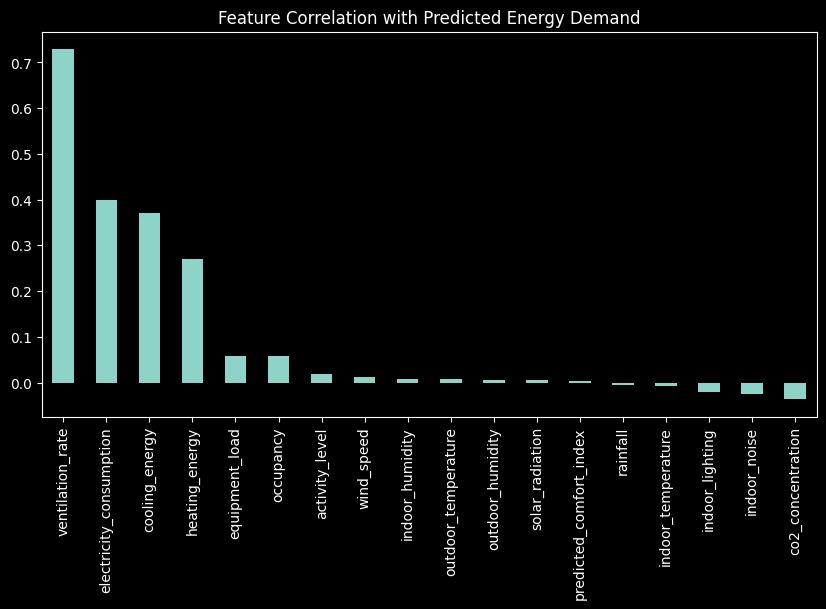

In [ ]:
corr.drop(target).plot(kind='bar', figsize=(10,5))
plt.title("Feature Correlation with Predicted Energy Demand")
plt.show()

In [ ]:
top_features = corr.abs().sort_values(ascending=False).head(8).index.tolist()
print(top_features)

['predicted_energy_demand', 'ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy', 'equipment_load', 'occupancy', 'co2_concentration']


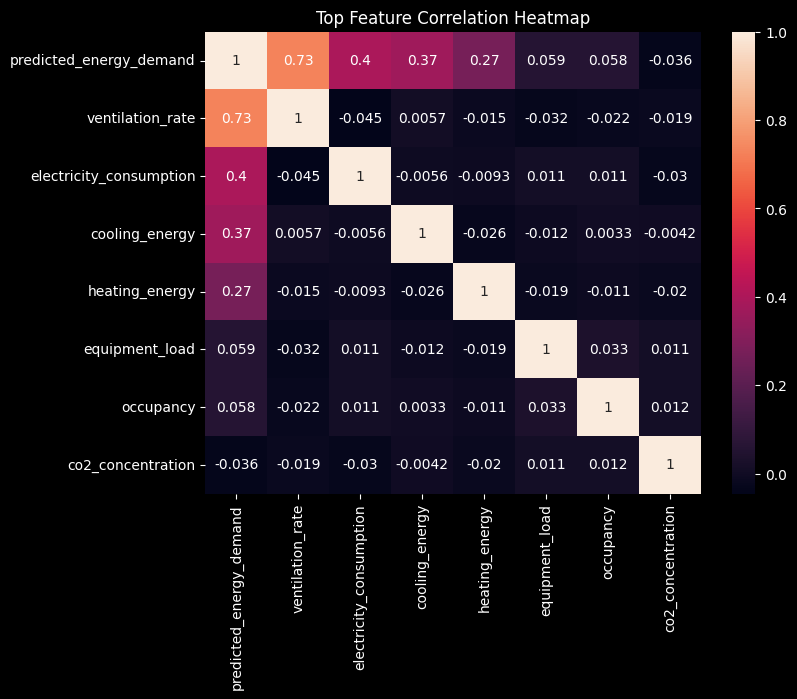

,predicted_energy_demand,ventilation_rate,electricity_consumption,cooling_energy,heating_energy,equipment_load,occupancy,co2_concentration
predicted_energy_demand,1.000000,0.728865,0.398703,0.370632,0.271304,0.058766,0.057655,-0.036466
ventilation_rate,0.728865,1.000000,-0.045413,0.005686,-0.014601,-0.031974,-0.021752,-0.019419
electricity_consumption,0.398703,-0.045413,1.000000,-0.005592,-0.009323,0.010548,0.011017,-0.029523
cooling_energy,0.370632,0.005686,-0.005592,1.000000,-0.025719,-0.012341,0.003264,-0.004194
heating_energy,0.271304,-0.014601,-0.009323,-0.025719,1.000000,-0.018955,-0.010974,-0.019944
equipment_load,0.058766,-0.031974,0.010548,-0.012341,-0.018955,1.000000,0.033005,0.011114
occupancy,0.057655,-0.021752,0.011017,0.003264,-0.010974,0.033005,1.000000,0.011694
co2_concentration,-0.036466,-0.019419,-0.029523,-0.004194,-0.019944,0.011114,0.011694,1.000000


In [ ]:
plt.figure(figsize=(8,6))
corr_top = df2[top_features].corr()
sns.heatmap(corr_top, annot=True)
plt.title("Top Feature Correlation Heatmap")
plt.show()
corr_top

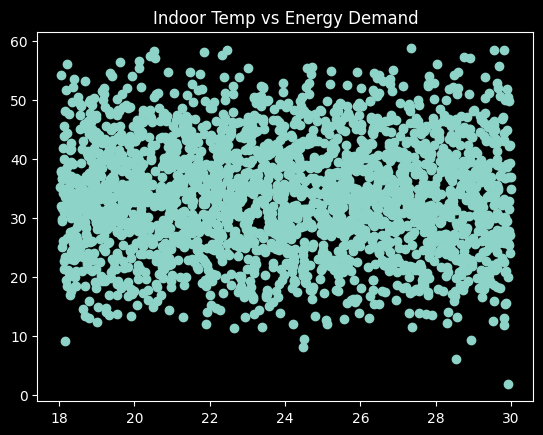

In [ ]:
plt.scatter(df2['indoor_temperature'], df2[target])
plt.title("Indoor Temp vs Energy Demand")
plt.show()

Expected environmental variables to matter:
- temperature
- humidity
- solar radiation
- occupancy

Instead:
| Feature                 | Correlation |
| ----------------------- | ----------: |
| ventilation_rate        |   **0.729** |
| electricity_consumption |   **0.399** |
| cooling_energy          |   **0.371** |
| heating_energy          |   **0.271** |


`* Other features are not important (noise) for predicting energy demand`

In [ ]:
df2[['predicted_energy_demand',
     'ventilation_rate',
     'electricity_consumption',
     'cooling_energy',
     'heating_energy']].describe()

,predicted_energy_demand,ventilation_rate,electricity_consumption,cooling_energy,heating_energy
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,33.724789,249.322350,24.796787,24.980710,19.557364
std,9.560419,144.429508,14.229819,14.405205,11.461431
min,1.831555,0.199846,0.005512,0.003375,0.005006
25%,27.114764,122.670289,12.651079,12.813325,9.458481
50%,33.577877,251.389623,24.760944,25.090347,19.643330
75%,40.417122,369.692475,36.686875,37.667744,29.188313
max,58.721555,499.848605,49.972526,49.986604,39.987824


In [ ]:
df2[['predicted_energy_demand',
     'ventilation_rate',
     'electricity_consumption',
     'cooling_energy',
     'heating_energy']].head(10)

,predicted_energy_demand,ventilation_rate,electricity_consumption,cooling_energy,heating_energy
0,39.936909,327.046999,34.276401,21.254016,18.919498
1,24.985061,144.862778,23.378548,18.000948,17.726091
2,39.675344,493.647357,2.785345,39.099193,19.930580
3,52.678350,475.091197,45.925508,37.267514,17.374061
4,48.824527,287.220492,49.016457,45.261246,21.653203
5,43.979955,421.604189,21.552171,19.774376,35.519412
6,32.259034,130.747244,30.683040,28.208976,25.313173
7,38.954254,208.018498,22.514931,44.615352,28.904835
8,26.914858,91.985880,16.093983,49.692403,23.899325
9,34.098538,260.051321,3.865940,48.464718,25.720707


`* Top variables do not appear trivially identical to the target.`

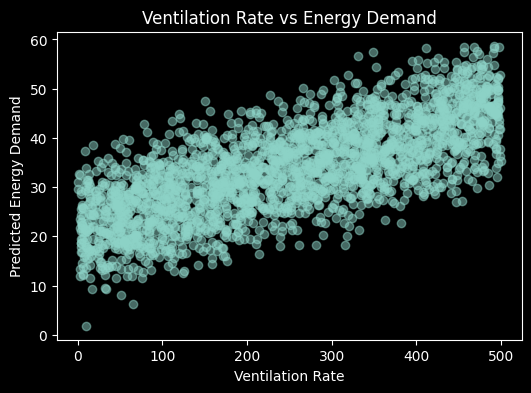

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df2['ventilation_rate'],
            df2['predicted_energy_demand'],
            alpha=0.5)

plt.xlabel("Ventilation Rate")
plt.ylabel("Predicted Energy Demand")
plt.title("Ventilation Rate vs Energy Demand")
plt.show()

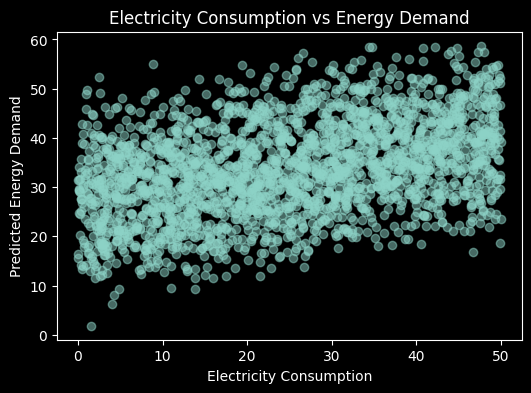

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df2['electricity_consumption'],
            df2['predicted_energy_demand'],
            alpha=0.5)

plt.xlabel("Electricity Consumption")
plt.ylabel("Predicted Energy Demand")
plt.title("Electricity Consumption vs Energy Demand")
plt.show()

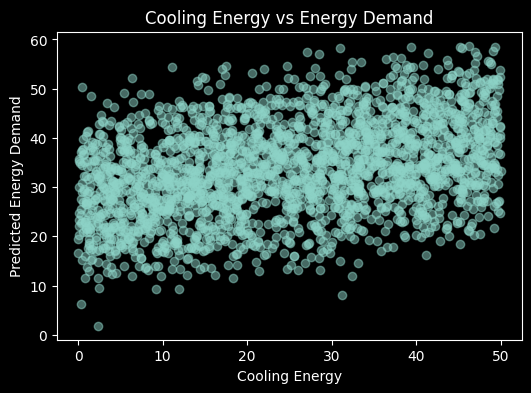

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df2['cooling_energy'],
            df2['predicted_energy_demand'],
            alpha=0.5)

plt.xlabel("Cooling Energy")
plt.ylabel("Predicted Energy Demand")
plt.title("Cooling Energy vs Energy Demand")
plt.show()

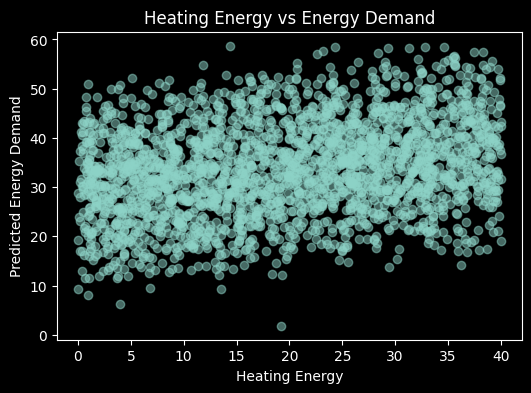

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df2['heating_energy'],
            df2['predicted_energy_demand'],
            alpha=0.5)

plt.xlabel("Heating Energy")
plt.ylabel("Predicted Energy Demand")
plt.title("Heating Energy vs Energy Demand")
plt.show()

In [ ]:
selected_features = [
    'ventilation_rate',
    'electricity_consumption',
    'cooling_energy',
    'heating_energy'
]

In [ ]:
df2[selected_features].corr()

,ventilation_rate,electricity_consumption,cooling_energy,heating_energy
ventilation_rate,1.000000,-0.045413,0.005686,-0.014601
electricity_consumption,-0.045413,1.000000,-0.005592,-0.009323
cooling_energy,0.005686,-0.005592,1.000000,-0.025719
heating_energy,-0.014601,-0.009323,-0.025719,1.000000


In [ ]:
X = df2[selected_features]
y = df2['predicted_energy_demand']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

R²   : 0.9490675290238755
MAE  : 1.7165846905673954
RMSE : 2.180577073472393


```
R² = 0.949 → ~95% variance explained
MAE = 1.72 → low average error
RMSE = 2.18 → prediction error is small relative to target scale (~mean ≈ 33.7)
```

This means a strong linear predictive relationship exists.

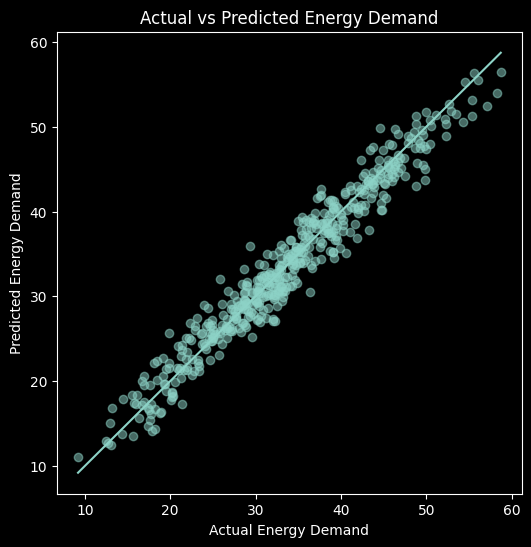

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title("Actual vs Predicted Energy Demand")

plt.show()

The predicted values closely followed the actual values with limited dispersion, confirming the suitability of a linear model.

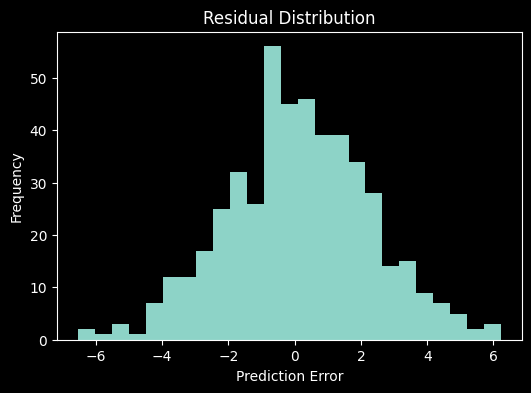

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=25)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

This means the model is unbiased.

Final findings:

1. Actual vs Predicted (/ shape)
- Predictions closely match actual values
- No visible curvature or clustering
- Error is uniformly distributed across range
```* This confirms high predictive fidelity```

2. Residual distribution (/\ shape)
- Errors are centered around zero
- Symmetric distribution
- No strong skewness or kurtosis
```* Model is unbiased```

3. R² = 0.949

```* ~95% of variability in energy demand is explained by a simple linear combination of 4 variables.```

4. Scientific conclusion

```
predicted_energy_demand ≈
a·ventilation_rate +
b·electricity_consumption +
c·cooling_energy +
d·heating_energy + bias
```

- The dataset is strongly linear in a low-dimensional energy subsystem space.


A linear regression model using ventilation rate, electricity consumption, cooling energy, and heating energy successfully explains approximately 95% of the variance in predicted energy demand. This indicates a strong linear dependency structure within the dataset, suggesting that energy demand can be effectively approximated using a small subset of energy-system variables.